# Plot restless-bandit choice variability and Q-value error metrics

This notebook reads the saved RB metric files and plots:

1. Entropy  
2. Switching  
3. Entropy + switching  
4. Q-value error  

It also prints all values at the end in one table.


In [7]:

# ==================================================
# Imports and paths
# ==================================================

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
# Assumes project_root is already defined in your notebook.

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

try:
    project_root
except NameError:
    project_root = os.getcwd()

metrics_dir = os.path.join(
    project_root,
    "results",
    "decision_making_tasks",
    "data",
    "non_stationary_bandits",
    "Case_2_difficult"
)

lat_arr = [0.0275, 0.0325, 0.0375, 0.0425, 0.0475]

normal_file = os.path.join(
    metrics_dir,
    "non_stationary_v2_choice_q_metrics_normal.pkl"
)

print("Metrics directory:", metrics_dir)
print("Normal file:", normal_file)


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making
Metrics directory: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/results/decision_making_tasks/data/non_stationary_bandits/Case_2_difficult
Normal file: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/results/decision_making_tasks/data/non_stationary_bandits/Case_2_difficult/non_stationary_v2_choice_q_metrics_normal.pkl


In [8]:

# ==================================================
# Helper functions
# ==================================================

def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def to_float(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return float(np.asarray(x))


def get_condition_key(type_list, possible_names):
    for name in possible_names:
        for t in type_list:
            if str(t).lower() == name.lower():
                return t

    for name in possible_names:
        for t in type_list:
            if name.lower() in str(t).lower():
                return t

    raise KeyError(f"Could not find condition from {possible_names}. Available TYPE = {type_list}")


def get_delta_key(monitor, condition_key, d):
    if d in monitor[condition_key]:
        return d

    try:
        if float(d) in monitor[condition_key]:
            return float(d)
    except Exception:
        pass

    available_keys = list(monitor[condition_key].keys())
    available_float = np.array(available_keys, dtype=float)
    return available_keys[np.argmin(np.abs(available_float - float(d)))]


def get_metric_array(monitor, condition_key, delta_vals, metric_key):
    vals = []

    for d in delta_vals:
        d_key = get_delta_key(monitor, condition_key, d)
        val = monitor[condition_key][d_key][metric_key]
        vals.append(to_float(val))

    return np.array(vals)


metric_specs = [
    {
        "title": "Entropy",
        "monitor_name": "CHOICE_VARIABILITY_METRICS_MONITOR",
        "metric_key": "mean_entropy",
        "ylabel": "Entropy",
        "normal_key": "entropy"
    },
    {
        "title": "Switching",
        "monitor_name": "CHOICE_VARIABILITY_METRICS_MONITOR",
        "metric_key": "mean_switching",
        "ylabel": "Switching",
        "normal_key": "switching"
    },
    {
        "title": "Entropy + switching",
        "monitor_name": "CHOICE_VARIABILITY_METRICS_MONITOR",
        "metric_key": "mean_combined_variability",
        "ylabel": "Choice variability",
        "normal_key": "entropy_plus_switching"
    },
    {
        "title": "Q-value error",
        "monitor_name": "Q_ERROR_METRICS_MONITOR",
        "metric_key": "mean_q_rmse",
        "ylabel": "DP value error",
        "normal_key": "q_error"
    },
]


In [9]:

# ==================================================
# Load normal metric values
# ==================================================

normal_data = load_pkl(normal_file)

normal_values = {
    "mean_entropy": to_float(normal_data["entropy"]),
    "mean_switching": to_float(normal_data["switching"]),
    "mean_combined_variability": to_float(normal_data["entropy_plus_switching"]),
    "mean_q_rmse": to_float(normal_data["q_error"]),
}

print("Normal values")
print("-------------")
print(f"Entropy              = {normal_values['mean_entropy']:.4f}")
print(f"Switching            = {normal_values['mean_switching']:.4f}")
print(f"Entropy + switching  = {normal_values['mean_combined_variability']:.4f}")
print(f"Q-value error        = {normal_values['mean_q_rmse']:.4f}")


Normal values
-------------
Entropy              = 0.1069
Switching            = 0.0566
Entropy + switching  = 0.0918
Q-value error        = 0.0764


In [10]:

# ==================================================
# Collect all RB metrics into one dataframe
# ==================================================

records = []

# Add normal row
records.append({
    "lat_strength": "normal",
    "condition": "Normal",
    "delta_lim": "no_limit",
    "entropy": normal_values["mean_entropy"],
    "switching": normal_values["mean_switching"],
    "entropy_plus_switching": normal_values["mean_combined_variability"],
    "q_error": normal_values["mean_q_rmse"],
})

for lat_strength in lat_arr:
    lat_str = str(lat_strength).replace(".", "_")

    metrics_file = os.path.join(
        metrics_dir,
        f"non_stationary_bandits_v2_choice_q_metrics_lat_{lat_str}.pkl"
    )

    if not os.path.exists(metrics_file):
        print(f"Skipping missing file: {metrics_file}")
        continue

    data = load_pkl(metrics_file)

    delta_vals = data["DEL_LIM_ARR"]
    type_list = data["TYPE"]

    pd_key = get_condition_key(type_list, ["PD"])
    dbs_key = get_condition_key(type_list, ["DBS", "sDBS", "PD-sDBS", "STD_DBS"])
    sector_key = get_condition_key(type_list, ["SECTOR_DBS", "sector DBS", "rDBS", "PD-rDBS"])

    condition_keys = [pd_key, dbs_key, sector_key]
    condition_labels = ["PD", "sDBS", "Sector DBS"]

    choice_monitor = data["CHOICE_VARIABILITY_METRICS_MONITOR"]
    q_monitor = data["Q_ERROR_METRICS_MONITOR"]

    for cond_key, cond_label in zip(condition_keys, condition_labels):
        entropy_vals = get_metric_array(
            choice_monitor, cond_key, delta_vals, "mean_entropy"
        )

        switching_vals = get_metric_array(
            choice_monitor, cond_key, delta_vals, "mean_switching"
        )

        combined_vals = get_metric_array(
            choice_monitor, cond_key, delta_vals, "mean_combined_variability"
        )

        q_error_vals = get_metric_array(
            q_monitor, cond_key, delta_vals, "mean_q_rmse"
        )

        for i, d in enumerate(delta_vals):
            records.append({
                "lat_strength": lat_strength,
                "condition": cond_label,
                "delta_lim": float(d),
                "entropy": entropy_vals[i],
                "switching": switching_vals[i],
                "entropy_plus_switching": combined_vals[i],
                "q_error": q_error_vals[i],
            })

metrics_df = pd.DataFrame(records)

print("Loaded metrics")
print("--------------")
print(metrics_df.head())
print()
print("Total rows:", len(metrics_df))


Loaded metrics
--------------
  lat_strength condition delta_lim   entropy  switching  \
0       normal    Normal  no_limit  0.106923   0.056561   
1       0.0275        PD       0.1  0.511843   0.319136   
2       0.0275        PD       0.2  0.015319   0.004659   
3       0.0275        PD       0.5  0.013314   0.003729   
4       0.0275        PD       1.0  0.014828   0.003953   

   entropy_plus_switching   q_error  
0                0.091815  0.076353  
1                0.454031  0.117371  
2                0.012121  0.092342  
3                0.010438  0.091649  
4                0.011566  0.092436  

Total rows: 61


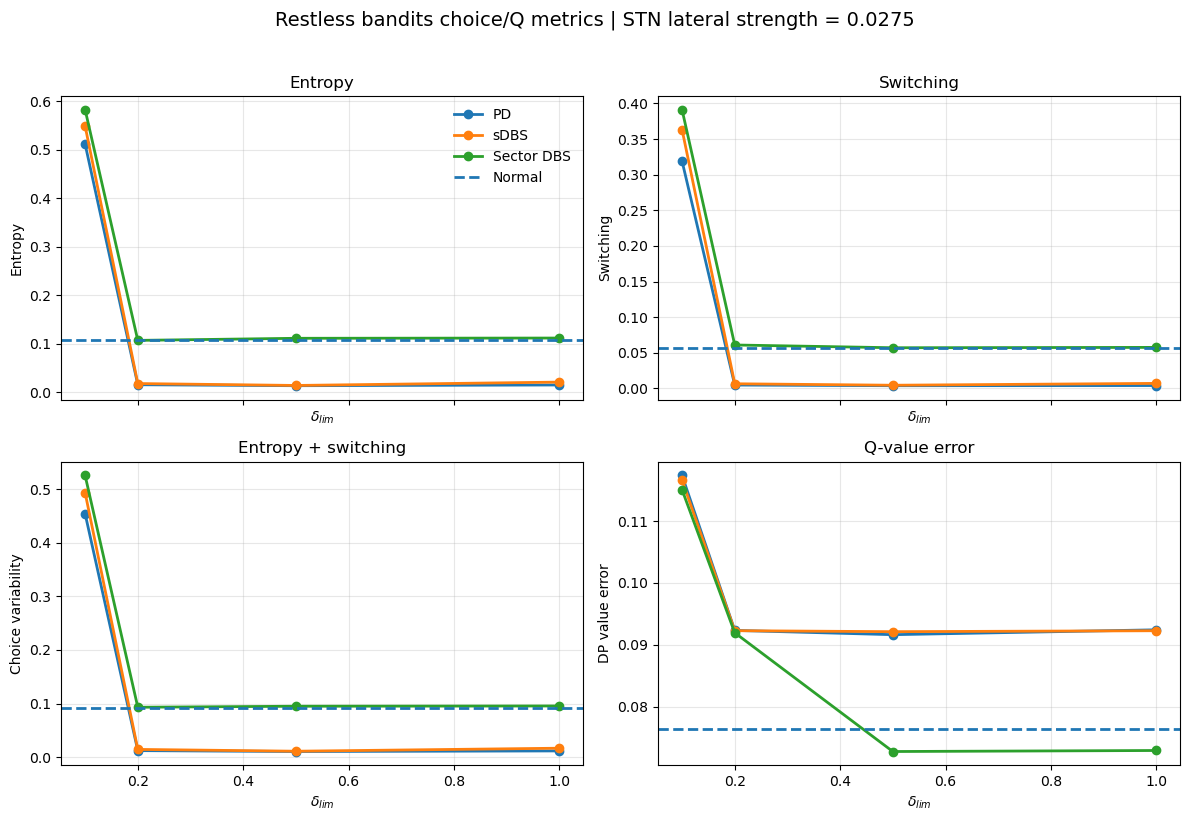

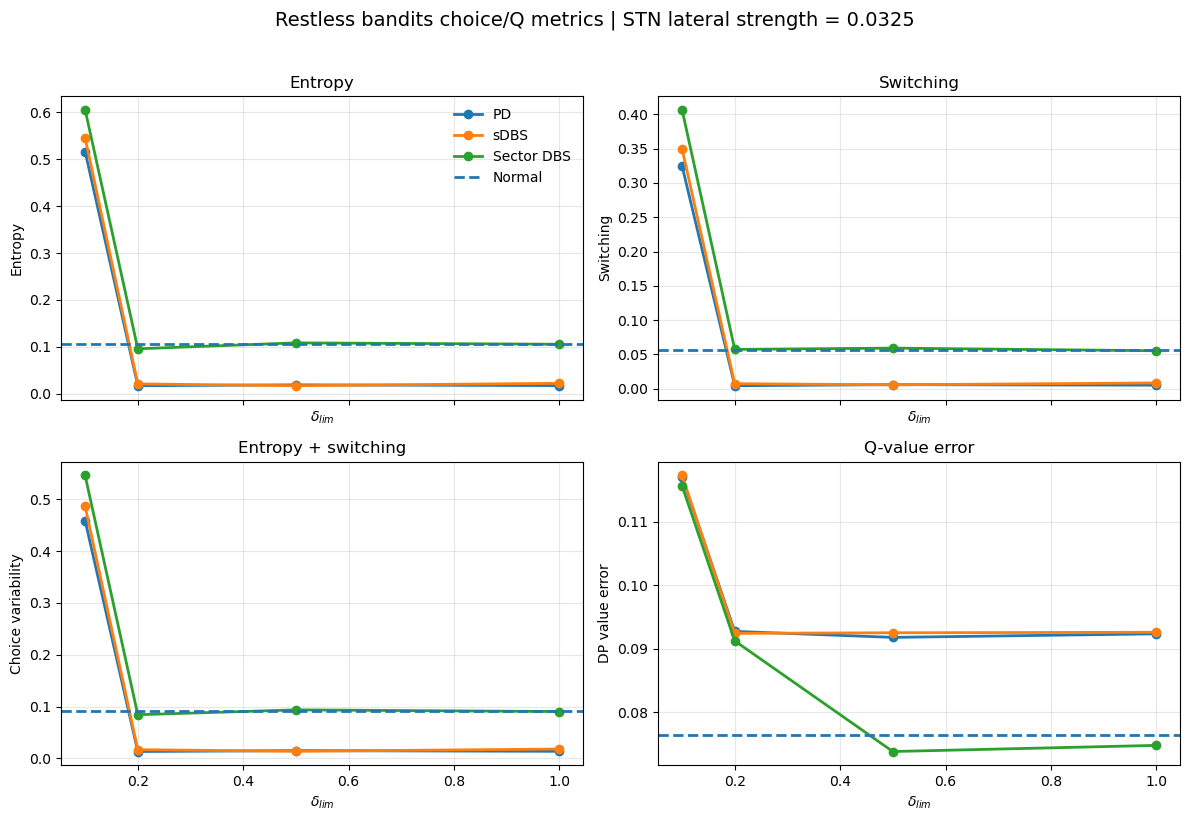

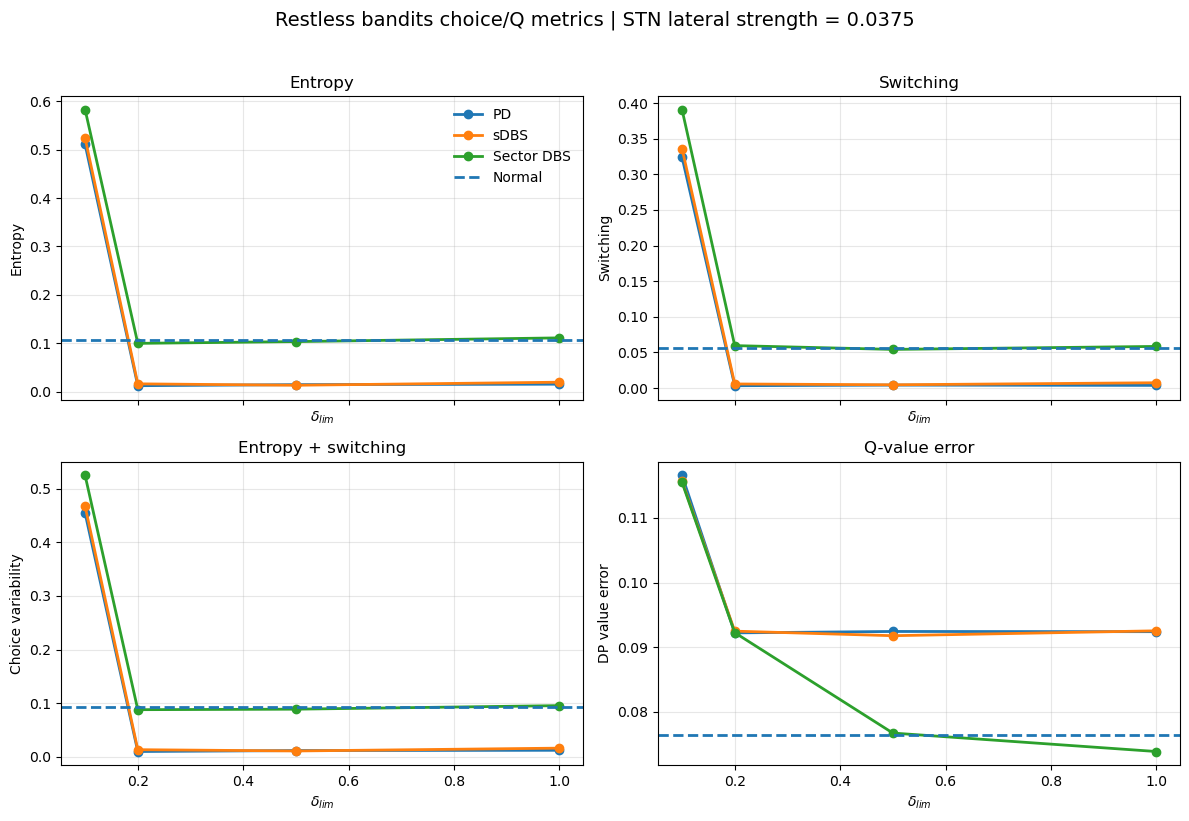

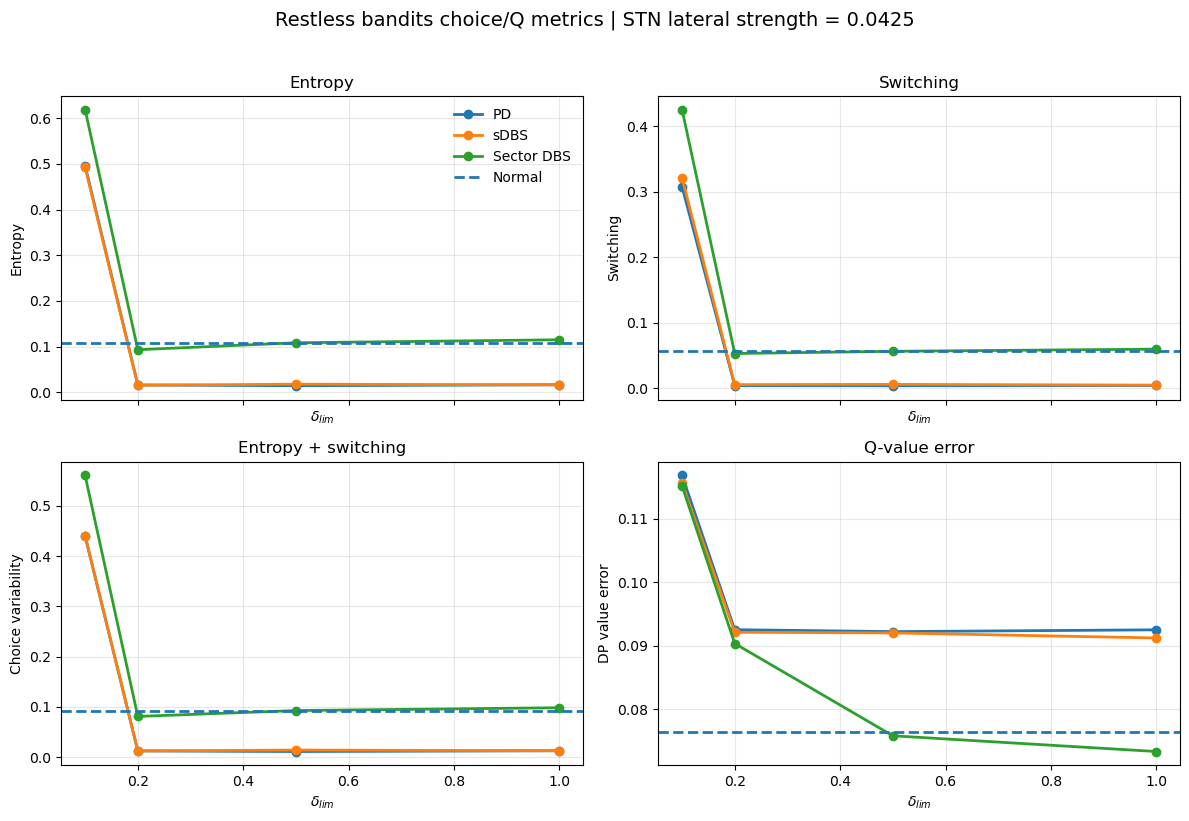

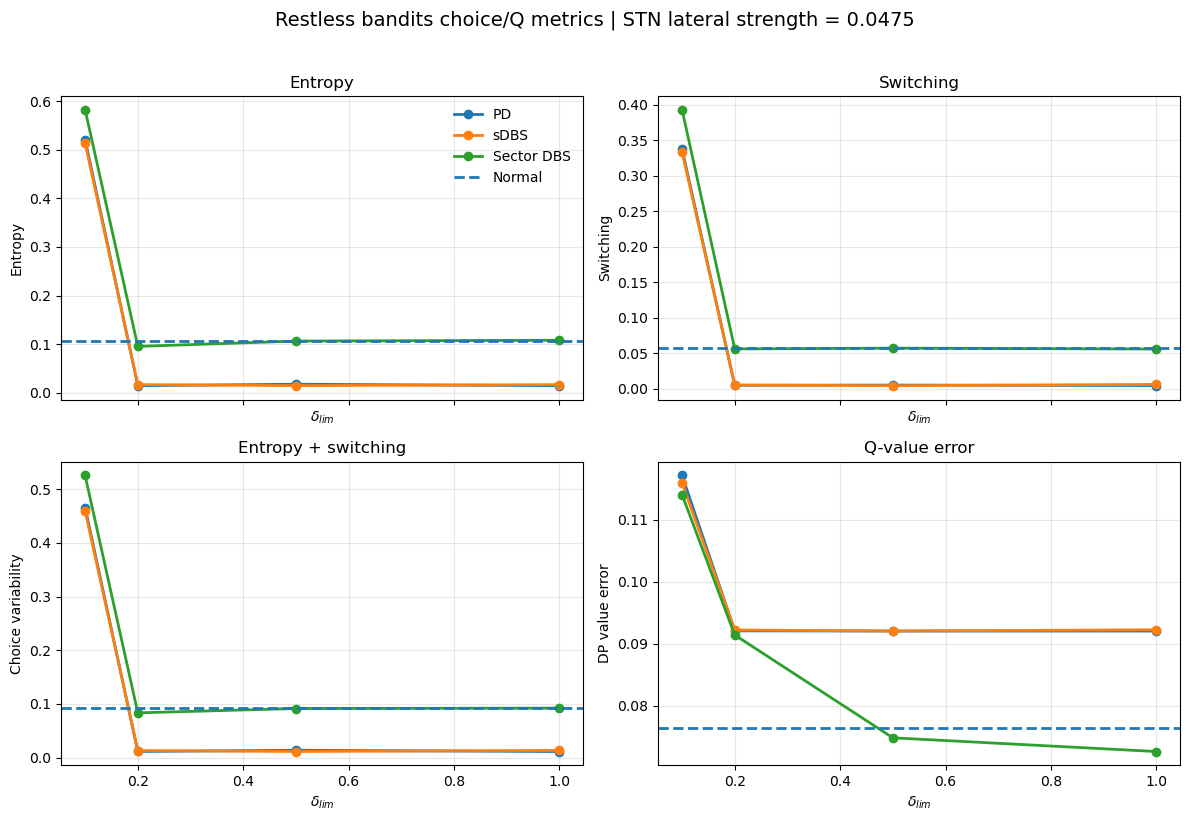

In [11]:

# ==================================================
# Plot each lateral strength separately
# ==================================================

plot_metrics = [
    ("entropy", "Entropy", "Entropy"),
    ("switching", "Switching", "Switching"),
    ("entropy_plus_switching", "Entropy + switching", "Choice variability"),
    ("q_error", "Q-value error", "DP value error"),
]

condition_order = ["PD", "sDBS", "Sector DBS"]

for lat_strength in lat_arr:
    df_lat = metrics_df[metrics_df["lat_strength"] == lat_strength].copy()

    if df_lat.empty:
        print(f"No data found for lateral strength {lat_strength}")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.ravel()

    for ax, (metric_col, title, ylabel) in zip(axes, plot_metrics):
        for cond in condition_order:
            df_cond = df_lat[df_lat["condition"] == cond].sort_values("delta_lim")

            if df_cond.empty:
                continue

            ax.plot(
                df_cond["delta_lim"].values,
                df_cond[metric_col].values,
                marker="o",
                linewidth=2,
                markersize=6,
                label=cond
            )

        normal_val = metrics_df.loc[
            metrics_df["condition"] == "Normal", metric_col
        ].iloc[0]

        ax.axhline(
            normal_val,
            linestyle="--",
            linewidth=2,
            label="Normal" if title == "Entropy" else None
        )

        ax.set_title(title)
        ax.set_xlabel(r"$\delta_{lim}$")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

    axes[0].legend(frameon=False)

    plt.suptitle(
        f"Restless bandits choice/Q metrics | STN lateral strength = {lat_strength}",
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


In [12]:

# ==================================================
# Print all metrics at the end
# ==================================================

display_cols = [
    "lat_strength",
    "condition",
    "delta_lim",
    "entropy",
    "switching",
    "entropy_plus_switching",
    "q_error",
]

metrics_print_df = metrics_df[display_cols].copy()

# Sort normal first, then by lateral strength, delta, and condition
condition_rank = {
    "Normal": 0,
    "PD": 1,
    "sDBS": 2,
    "Sector DBS": 3,
}

metrics_print_df["condition_rank"] = metrics_print_df["condition"].map(condition_rank)

metrics_print_df["lat_sort"] = metrics_print_df["lat_strength"].apply(
    lambda x: -1 if x == "normal" else float(x)
)

metrics_print_df["delta_sort"] = metrics_print_df["delta_lim"].apply(
    lambda x: -1 if x == "no_limit" else float(x)
)

metrics_print_df = metrics_print_df.sort_values(
    ["lat_sort", "delta_sort", "condition_rank"]
).drop(columns=["lat_sort", "delta_sort", "condition_rank"])

print("All RB choice/Q metrics")
print("=======================")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

display(metrics_print_df)

# Optional: also save the printed table as CSV
csv_file = os.path.join(metrics_dir, "non_stationary_bandits_v1_choice_q_metrics_summary.csv")
metrics_print_df.to_csv(csv_file, index=False)

print(f"\nSaved summary table: {csv_file}")


All RB choice/Q metrics


,lat_strength,condition,delta_lim,entropy,switching,entropy_plus_switching,q_error
0,normal,Normal,no_limit,0.106923,0.056561,0.091815,0.076353
1,0.0275,PD,0.1,0.511843,0.319136,0.454031,0.117371
5,0.0275,sDBS,0.1,0.548972,0.363439,0.493312,0.116617
9,0.0275,Sector DBS,0.1,0.582917,0.391346,0.525446,0.115065
2,0.0275,PD,0.2,0.015319,0.004659,0.012121,0.092342
6,0.0275,sDBS,0.2,0.017749,0.006453,0.014360,0.092294
10,0.0275,Sector DBS,0.2,0.106797,0.060897,0.093027,0.091960
3,0.0275,PD,0.5,0.013314,0.003729,0.010438,0.091649
7,0.0275,sDBS,0.5,0.013819,0.004377,0.010986,0.092134
11,0.0275,Sector DBS,0.5,0.111131,0.057027,0.094900,0.072774



Saved summary table: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/results/decision_making_tasks/data/non_stationary_bandits/Case_2_difficult/non_stationary_bandits_v1_choice_q_metrics_summary.csv
